In [ ]:
!pip install kaggle

!kaggle datasets download -d nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone --unzip -p ./ct_kidney

Dataset URL: https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone
License(s): copyright-authors
100% 1.52G/1.52G [00:16<00:00, 98.7MB/s]



In [ ]:

# 1. IMPORTS

import os
from glob import glob
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder





#2.LOAD DATA

dataset_dir = "./ct_kidney"

image_paths = glob(os.path.join(dataset_dir, "**/*.jpg"), recursive=True)
labels = [os.path.basename(os.path.dirname(p)) for p in image_paths]

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
print(df.head())


# 4. ENCODE LABELS

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])


# 5. TRAIN-VAL-TEST SPLIT

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label_enc'], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.1, stratify=train_df['label_enc'], random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


# 6. IMAGE GENERATORS

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)


# 7. LIGHTNET MODEL

def build_lightnet(input_shape=(224,224,3), num_classes=4):

    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    # Block 2
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    # Block 3
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    # Block 4
    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Global Pooling
    x = GlobalAveragePooling2D()(x)

    # Dense Layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(4, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


model = build_lightnet()
model.summary()

# 8. COMPILE MODEL

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# 9. CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)



# 10. TRAIN MODEL

EPOCHS = 10

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)



# 11. EVALUATE MODEL

loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc * 100:.2f}%")

Total images: 12446
                                          image_path  label
0  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Tumor
1  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Tumor
2  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Tumor
3  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Tumor
4  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Tumor
Train: 8960, Val: 996, Test: 2490
Found 8960 validated image filenames belonging to 4 classes.
Found 996 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 148s 244ms/step - accuracy: 0.7070 - loss: 0.7370 - val_accuracy: 0.4719 - val_loss: 1.8633 - learning_rate: 0.0010
Epoch 2/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 132s 236ms/step - accuracy: 0.7998 - loss: 0.5085 - val_accuracy: 0.6034 - val_loss: 1.5917 - learning_rate: 0.0010
Epoch 3/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 132s 236ms/step - accuracy: 0.8757 - loss: 0.3382 - val_accuracy: 0.8243 - val_loss: 0.5882 - learning_rate: 0.0010
Epoch 4/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 135s 240ms/step - accuracy: 0.9142 - loss: 0.2328 - val_accuracy: 0.5050 - val_loss: 3.0615 - learning_rate: 0.0010
Epoch 5/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 134s 238ms/step - accuracy: 0.9406 - loss: 0.1675 - val_accuracy: 0.8745 - val_loss: 0.4398 - learning_rate: 0.0010
Epoch 6/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 133s 237ms/step - accuracy: 0.9596 - loss: 0.1179 - val_accuracy: 0.9378 - val_loss: 0.1908 - learning_rate: 0.0010
Epoch 7/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 134s 240ms/step - accura

156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step


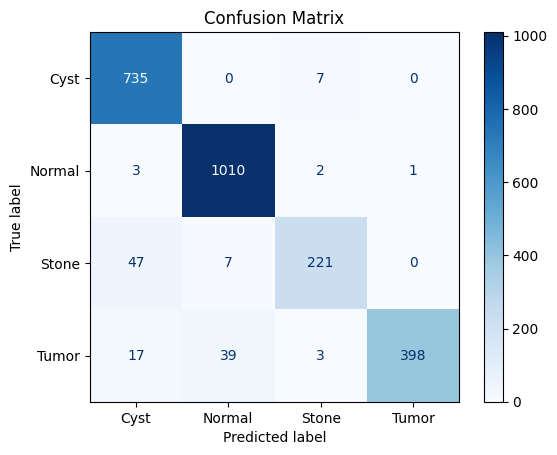

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


# 1. Confusion Matrix
# Get predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes  # true labels from generator

# Display confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(cm, display_labels=test_gen.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

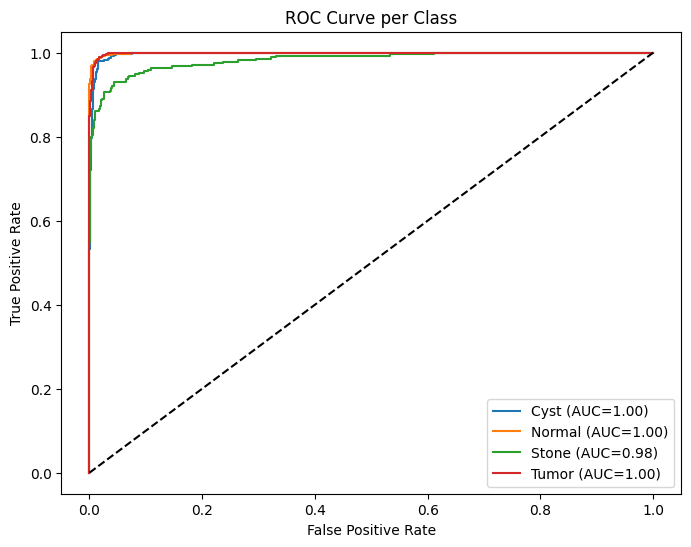

In [ ]:
# --- 2. ROC Curves for Each Class ---
from sklearn.preprocessing import label_binarize

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=list(range(len(test_gen.class_indices))))
plt.figure(figsize=(8,6))

for i, class_name in enumerate(test_gen.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve per Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()







1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step


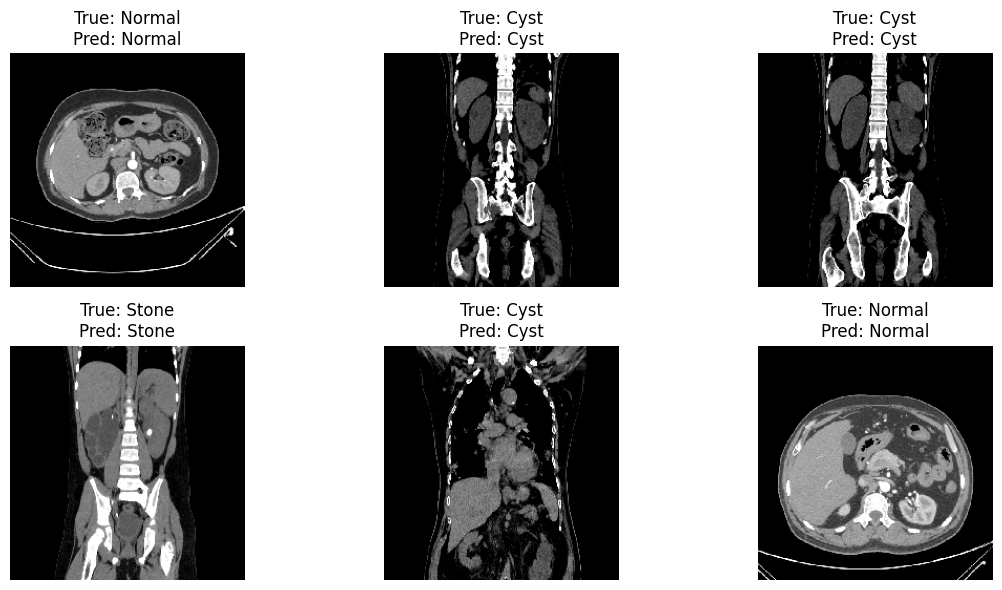

In [ ]:
# --- 3. Sample Predictions ---
import matplotlib.pyplot as plt

# Get some sample images from the generator
test_images, test_labels = next(test_gen)  # first batch
pred_classes = np.argmax(model.predict(test_images), axis=1)
true_classes = np.argmax(test_labels, axis=1)

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(test_images[i])
    plt.title(f"True: {list(test_gen.class_indices.keys())[true_classes[i]]}\nPred: {list(test_gen.class_indices.keys())[pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

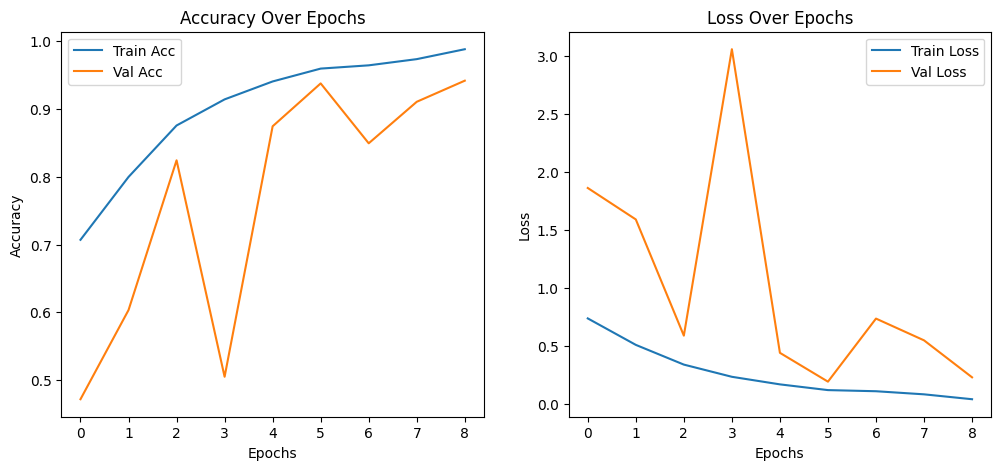

In [ ]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()